# Similitud entre columnas, antes de TOPSIS

Este cuaderno revisa el archivo `Municipio con ICEE menor a 95 por ciento.csv` para ver qué columnas repiten información y cuáles se mueven juntas.

Eso importa para TOPSIS. Cada columna que entre al modelo es un criterio. Si dos criterios son la misma serie, o uno es la suma de otros, ese aspecto pesa dos veces en la priorización. Aquí todavía no se define si un criterio es costo o beneficio: solo se alista la matriz.

Los nombres, el departamento y el DIVIPOLA identifican al municipio. No entran como criterios.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda valor: f"{valor:,.3f}")

NOMBRE = "Municipio con ICEE menor a 95 por ciento.csv"

def encontrar_tabla():
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidato = base / "datos" / NOMBRE
        if candidato.exists():
            return candidato
    raise FileNotFoundError(f"No está datos/{NOMBRE} a partir de {Path.cwd()}")

tabla = encontrar_tabla()
df = pd.read_csv(tabla, sep=";", decimal=",")
df["DIVIPOLA MUNICIPIO"] = df["DIVIPOLA MUNICIPIO"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(5)

numericas = [
    "HOGARES SIN SERVICIO",
    "NBI",
    "ICEE",
    "VSS Urbano",
    "VSS Rural",
    "VSS Total",
    "mdm",
    "POBLACION",
]
binarias = ["PDET", "ZOMAC"]

print(f"{len(df)} municipios y {df.shape[1]} columnas")
print("Archivo:", tabla)
df.head(3)

744 municipios y 14 columnas
Archivo: /Users/cristiantorres/Desktop/work/dnp/bi/datos/Municipio con ICEE menor a 95 por ciento.csv


,NOMBRE DEPARTAMENTO,NOMBRE MUNICIPIO,DIVIPOLA MUNICIPIO,HOGARES SIN SERVICIO,NBI,ICEE,CATEGORIA,PDET,ZOMAC,VSS Urbano,VSS Rural,VSS Total,mdm,POBLACION
0,"Bogotá, D,C,","Bogotá, D,C,",11001,209930,3.470,92.690,ESP,0,0,209930,0,209930,58.640,7918660
1,Cundinamarca,Soacha,25754,72149,5.370,77.840,1,0,0,72149,0,72149,53.790,842579
2,Valle del Cauca,Cali,76001,69566,4.110,91.520,ESP,0,0,67085,2481,69566,83.040,2280171


## Qué hay en cada columna

`HOGARES SIN SERVICIO`, `VSS Urbano`, `VSS Rural` y `VSS Total` son conteos de viviendas sin servicio. `POBLACION` es la proyección de 2024 para el área geográfica Total. `ICEE`, `NBI` y `mdm` son índices. `PDET` y `ZOMAC` valen 1 si el municipio pertenece a esa clasificación. `CATEGORIA` es la categoría administrativa (1 a 6, o ESP).

In [2]:
vacios = df[numericas + binarias + ["CATEGORIA"]].isna().sum().rename("vacios")
vacios = vacios.to_frame()
vacios["municipios"] = len(df)
display(vacios)

print("Categoría administrativa")
display(df["CATEGORIA"].value_counts(dropna=False).rename("municipios").to_frame())

,vacios,municipios
HOGARES SIN SERVICIO,0,744
NBI,1,744
ICEE,0,744
VSS Urbano,0,744
VSS Rural,0,744
VSS Total,0,744
mdm,19,744
POBLACION,0,744
PDET,0,744
ZOMAC,0,744


Categoría administrativa


,municipios
CATEGORIA,
6,671
5,21
NaN,19
4,11
2,9
1,6
3,4
ESP,3


## Columnas que son la misma serie

Dos columnas repiten información cuando coinciden municipio a municipio, o cuando una es una cuenta exacta de otras. Eso es más fuerte que una correlación alta: no queda residuo.

In [3]:
comparacion = pd.DataFrame({
    "municipios comparados": [df[["HOGARES SIN SERVICIO", "VSS Total"]].dropna().shape[0]],
    "diferencia máxima": [(df["HOGARES SIN SERVICIO"] - df["VSS Total"]).abs().max()],
}, index=["HOGARES SIN SERVICIO frente a VSS Total"])

suma = df["VSS Urbano"] + df["VSS Rural"]
comparacion.loc["VSS Urbano + VSS Rural frente a VSS Total"] = [
    df[["VSS Urbano", "VSS Rural", "VSS Total"]].dropna().shape[0],
    (suma - df["VSS Total"]).abs().max(),
]
display(comparacion)

print(
    "HOGARES SIN SERVICIO y VSS Total son la misma columna."
    if comparacion.loc["HOGARES SIN SERVICIO frente a VSS Total", "diferencia máxima"] == 0
    else "HOGARES SIN SERVICIO y VSS Total no coinciden en todos los municipios."
)
print(
    "VSS Total es la suma de VSS Urbano y VSS Rural."
    if comparacion.loc["VSS Urbano + VSS Rural frente a VSS Total", "diferencia máxima"] == 0
    else "VSS Total no es la suma exacta de urbano y rural."
)

,municipios comparados,diferencia máxima
HOGARES SIN SERVICIO frente a VSS Total,744,0
VSS Urbano + VSS Rural frente a VSS Total,744,0


HOGARES SIN SERVICIO y VSS Total son la misma columna.
VSS Total es la suma de VSS Urbano y VSS Rural.


## Correlación entre las columnas numéricas

La correlación de Pearson va de −1 a 1. Cerca de 1, las dos columnas suben juntas. Cerca de −1, una sube cuando la otra baja. Cerca de 0, no se acompañan.

Un valor alto todavía no dice que midan el mismo concepto. Un municipio grande puede tener más viviendas sin servicio y más población, y aun así tener una cobertura distinta.

,columna A,columna B,correlación
0,HOGARES SIN SERVICIO,VSS Total,1.000
1,VSS Urbano,POBLACION,0.957
2,HOGARES SIN SERVICIO,VSS Urbano,0.948
3,VSS Urbano,VSS Total,0.948
4,VSS Total,POBLACION,0.928
5,HOGARES SIN SERVICIO,POBLACION,0.928
6,NBI,ICEE,-0.527
7,NBI,mdm,-0.436
8,HOGARES SIN SERVICIO,VSS Rural,0.341
9,VSS Rural,VSS Total,0.341


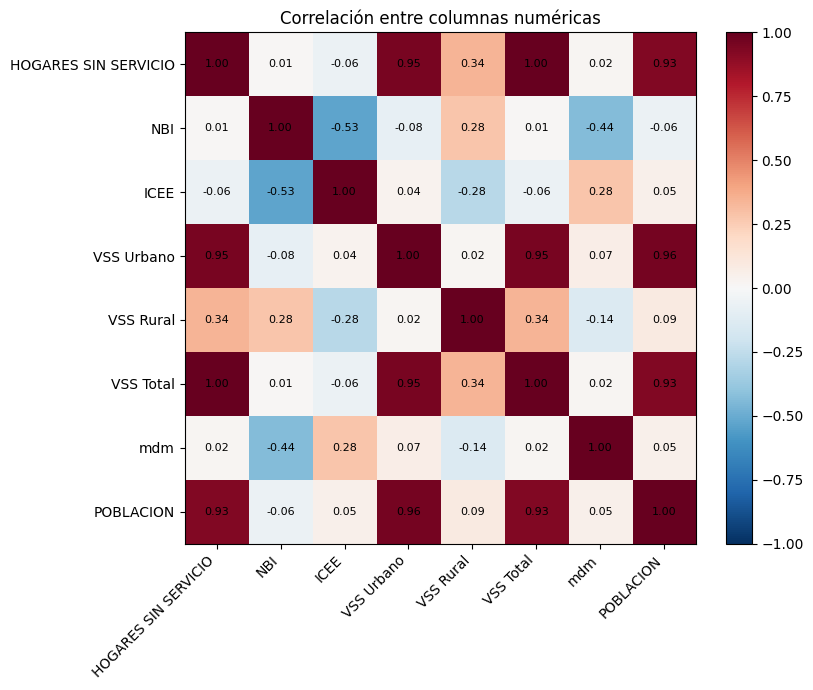

Pares con correlación absoluta de 0,90 o más:


,columna A,columna B,correlación
0,HOGARES SIN SERVICIO,VSS Total,1.000
1,VSS Urbano,POBLACION,0.957
2,HOGARES SIN SERVICIO,VSS Urbano,0.948
3,VSS Urbano,VSS Total,0.948
4,VSS Total,POBLACION,0.928
5,HOGARES SIN SERVICIO,POBLACION,0.928


Pares entre 0,40 y 0,90:


,columna A,columna B,correlación
0,NBI,ICEE,-0.527
1,NBI,mdm,-0.436


In [4]:
correlacion = df[numericas].corr()

def pares_ordenados(matriz):
    filas = []
    for i, izquierda in enumerate(matriz.columns):
        for derecha in matriz.columns[i + 1:]:
            filas.append({
                "columna A": izquierda,
                "columna B": derecha,
                "correlación": matriz.loc[izquierda, derecha],
                "valor absoluto": abs(matriz.loc[izquierda, derecha]),
            })
    return pd.DataFrame(filas).sort_values("valor absoluto", ascending=False)

pares = pares_ordenados(correlacion)
display(pares.drop(columns="valor absoluto").reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 7))
imagen = ax.imshow(correlacion, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numericas)))
ax.set_yticks(range(len(numericas)))
ax.set_xticklabels(numericas, rotation=45, ha="right")
ax.set_yticklabels(numericas)
for i in range(len(numericas)):
    for j in range(len(numericas)):
        ax.text(j, i, f"{correlacion.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(imagen, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlación entre columnas numéricas")
fig.tight_layout()
plt.show()

fuertes = pares[pares["valor absoluto"] >= 0.9]
moderadas = pares[(pares["valor absoluto"] >= 0.4) & (pares["valor absoluto"] < 0.9)]
print("Pares con correlación absoluta de 0,90 o más:")
display(fuertes.drop(columns="valor absoluto").reset_index(drop=True))
print("Pares entre 0,40 y 0,90:")
display(moderadas.drop(columns="valor absoluto").reset_index(drop=True))

## El tamaño del municipio

`VSS Urbano` y `VSS Total` crecen con la población. Para ver la cobertura, aparte del tamaño, se divide el conteo por `POBLACION` y se vuelve a correlacionar con `ICEE`, `NBI` y `mdm`.

In [5]:
tasas = pd.DataFrame(index=df.index)
for columna in ["HOGARES SIN SERVICIO", "VSS Urbano", "VSS Rural", "VSS Total"]:
    tasas[f"{columna} por habitante"] = df[columna] / df["POBLACION"]

referencia = df[["ICEE", "NBI", "mdm", "POBLACION"]]
corr_tasas = pd.concat([tasas, referencia], axis=1).corr().loc[
    tasas.columns, referencia.columns
]
display(corr_tasas)

,ICEE,NBI,mdm,POBLACION
HOGARES SIN SERVICIO por habitante,-0.819,0.210,-0.095,-0.073
VSS Urbano por habitante,-0.264,-0.182,0.127,0.008
VSS Rural por habitante,-0.759,0.326,-0.183,-0.084
VSS Total por habitante,-0.819,0.210,-0.095,-0.073


## PDET y ZOMAC

Son clasificaciones de sí o no. La correlación dice si se parecen. La tabla de cruces dice cuántos municipios caen en cada combinación. Si casi todos los PDET también son ZOMAC, usar las dos refuerza dos veces a ese grupo.

In [6]:
cruce = pd.crosstab(df["PDET"], df["ZOMAC"], margins=True)
cruce.index = ["PDET 0", "PDET 1", "Total"]
cruce.columns = ["ZOMAC 0", "ZOMAC 1", "Total"]
display(cruce)

columnas_binarias = numericas + binarias
corr_binarias = df[columnas_binarias].corr().loc[binarias, numericas + binarias]
display(corr_binarias)

,ZOMAC 0,ZOMAC 1,Total
PDET 0,496,126,622
PDET 1,3,119,122
Total,499,245,744


,HOGARES SIN SERVICIO,NBI,ICEE,VSS Urbano,VSS Rural,VSS Total,mdm,POBLACION,PDET,ZOMAC
PDET,0.065,0.275,-0.075,0.004,0.192,0.065,-0.190,0.006,1.000,0.609
ZOMAC,-0.012,0.179,-0.021,-0.047,0.100,-0.012,-0.147,-0.032,0.609,1.000


## Colinealidad (VIF)

El VIF responde otra pregunta: ¿esta columna se puede reconstruir con todas las demás a la vez?

Se calcula solo con los municipios que tienen las columnas completas. `mdm` está vacío en las áreas no municipalizadas y `NBI` falta en un municipio, así que esas filas salen de esta cuenta.

Un VIF cercano a 1 indica que la columna aporta algo que las otras no contienen. Un VIF alto indica que las demás ya la explican. Si una columna es una suma exacta de otras, la matriz no se puede invertir: la redundancia es perfecta.

In [7]:
def vif(columnas):
    completo = df[columnas].dropna()
    estandar = (completo - completo.mean()) / completo.std(ddof=0)
    matriz = np.corrcoef(estandar.to_numpy(), rowvar=False)
    condicion = np.linalg.cond(matriz)
    if condicion > 1e10:
        return len(completo), None, condicion
    inversa = np.linalg.inv(matriz)
    resultado = pd.Series(np.diag(inversa), index=columnas, name="VIF")
    return len(completo), resultado.sort_values(ascending=False), condicion

conjunto_completo = ["NBI", "ICEE", "VSS Urbano", "VSS Rural", "VSS Total", "mdm", "POBLACION", "PDET", "ZOMAC"]
n_completo, vif_completo, condicion_completa = vif(conjunto_completo)
print(f"Municipios con datos completos: {n_completo}")
if vif_completo is None:
    print(
        "Con VSS Urbano, VSS Rural y VSS Total juntas, el VIF no es interpretable: "
        "VSS Total es la suma de las otras dos y la matriz queda singular."
    )
else:
    display(vif_completo.to_frame())

conjunto_sin_total = ["NBI", "ICEE", "VSS Urbano", "VSS Rural", "mdm", "POBLACION", "PDET", "ZOMAC"]
n_reducido, vif_reducido, _ = vif(conjunto_sin_total)
print(f"Sin VSS Total ni HOGARES SIN SERVICIO. Municipios: {n_reducido}")
display(vif_reducido.to_frame())

Municipios con datos completos: 725
Con VSS Urbano, VSS Rural y VSS Total juntas, el VIF no es interpretable: VSS Total es la suma de las otras dos y la matriz queda singular.
Sin VSS Total ni HOGARES SIN SERVICIO. Municipios: 725


,VIF
POBLACION,13.091
VSS Urbano,13.001
PDET,1.717
NBI,1.638
ZOMAC,1.601
ICEE,1.406
VSS Rural,1.316
mdm,1.259


## Lectura para armar la matriz de TOPSIS

Con estos datos, la matriz de criterios puede evitar tres repeticiones:

- `HOGARES SIN SERVICIO` y `VSS Total` son el mismo número. Entra una.
- `VSS Total` es `VSS Urbano` más `VSS Rural`. Las tres juntas cuentan el déficit de viviendas dos veces. `VSS Urbano` y `VSS Rural` sí miden cosas distintas: casi no se correlacionan entre sí.
- `VSS Urbano` y `POBLACION` se mueven juntas porque el conteo urbano crece con el tamaño del municipio. Si el criterio es el tamaño, entra la población. Si el criterio es la cobertura, entra el `ICEE`, o el conteo dividido por la población. Esa tasa y el `ICEE` se mueven en sentido contrario con fuerza.

`NBI`, `mdm`, `ICEE`, `VSS Rural`, `PDET` y `ZOMAC` dejan información que las otras no reemplazan. `PDET` y `ZOMAC` se parecen a medias: la mayoría de los municipios PDET también son ZOMAC, y hay municipios ZOMAC que no son PDET. Usar las dos refuerza al grupo que está en ambas.

`CATEGORIA` está concentrada en la categoría 6, así que separa poco a los municipios. El departamento, el nombre y el DIVIPOLA identifican la fila.

TOPSIS necesita una matriz completa. Antes de correrlo hay que decidir qué hacer con los municipios sin `mdm` y con el municipio sin `NBI`. La decisión de si cada criterio es costo o beneficio va después de cerrar esta lista.